In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn import datasets

In [4]:
diabetes=datasets.load_diabetes(as_frame=True).frame


In [7]:
diabetes.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [9]:
X=diabetes.drop(columns=['target'],axis=1)
y=diabetes['target']

In [13]:
X.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [14]:
y.head()

0    151.0
1     75.0
2    141.0
3    206.0
4    135.0
Name: target, dtype: float64

In [15]:
diabetes.shape

(442, 11)

In [17]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)
model=DecisionTreeRegressor(max_depth=7,min_samples_split=20,min_samples_leaf=20)

model.fit(X_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,7
,min_samples_split,20
,min_samples_leaf,20
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [18]:
from sklearn.metrics import r2_score,mean_squared_error

y_pred_train=model.predict(X_train)
y_pred_test=model.predict(X_test)

print("Mse is ",mean_squared_error(y_train,y_pred_train))
print("Mse is ",mean_squared_error(y_test,y_pred_test))

print("r2 score is  ",r2_score(y_train,y_pred_train))
print("r2 score is  ",r2_score(y_test,y_pred_test))

Mse is  2712.48075111857
Mse is  3258.996155814711
r2 score is   0.5536038381089772
r2 score is   0.38488055637002505


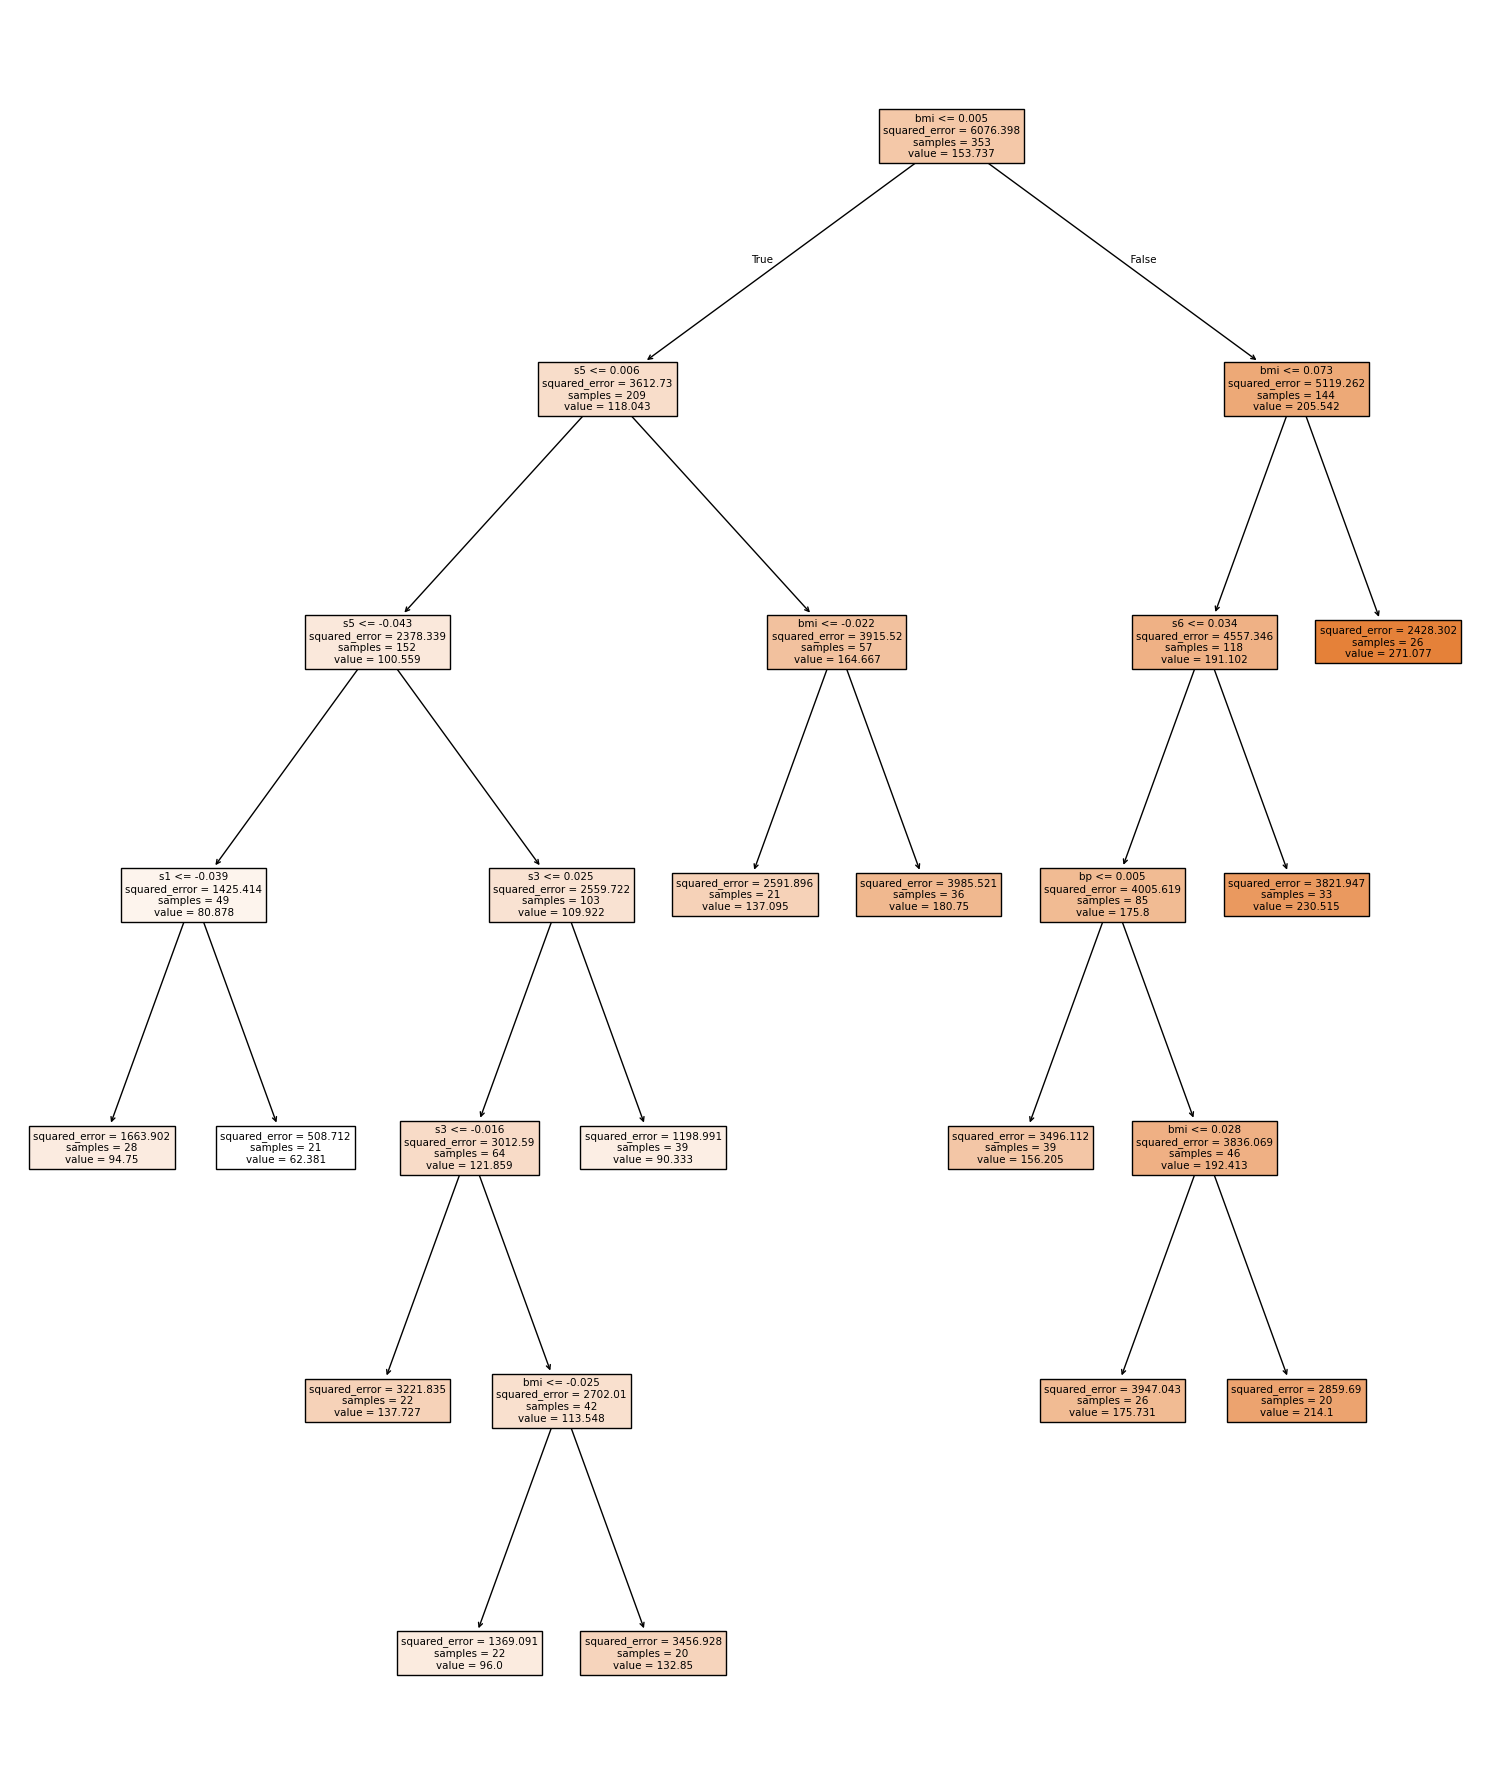

In [19]:
from sklearn.tree import plot_tree

plt.figure(figsize=(15,18))

plot_tree(
    model,
    feature_names=X.columns,
    
    filled=True
)
plt.tight_layout()
plt.show()

Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor


rf=RandomForestRegressor(
    n_estimators=301,
    oob_score=True
)

In [21]:
rf.fit(X_train,y_train)

c:\Users\HP\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:513: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y)


,n_estimators,301
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [ ]:
y_pred=rf.predict(X_test)


In [27]:
print("OOB score is",rf.oob_score_*100,"%")
print("R2 Score:", r2_score(y_test, y_pred))


OOB score is 43.01097169579714 %
R2 Score: 0.42772254187148584


In [30]:
#Baggging Regressor
from sklearn.ensemble import BaggingRegressor

base_model = DecisionTreeRegressor()

bagging=BaggingRegressor(
    base_model,
    n_estimators=301
)


bagging.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("r2 score is",r2_score(y_test,y_pred))


r2 score is 0.38488055637002505
